In [12]:
import simpy
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [13]:
random.seed(42)
np.random.seed(42)

In [14]:
# --- Función de formato de tiempo ---
def obtener_tiempo(minutos):
    minutos = int(minutos)
    return f"{(minutos//60)%24:02d}:{minutos%60:02d} día {minutos//(60*24)}"

# --- Clase Fabrica para centralizar recursos y contadores ---
class Fabrica:
    def __init__(self, env, critical_point, verbose=False):
        self.env = env
        self.critical_point = critical_point
        self.verbose = verbose 
        
        # Stocks de materiales (Containers para medir niveles)
        self.copper = simpy.Container(env, init=500, capacity=500)
        self.aluminum = simpy.Container(env, init=500, capacity=500)
        
        # Recursos 
        self.rotor_robots = simpy.Resource(env, capacity=2)
        self.stator_robots = simpy.Resource(env, capacity=2)
        self.rotor_inspectors = simpy.Resource(env, capacity=2)
        self.stator_inspectors = simpy.Resource(env, capacity=2)
        self.assembly_lines = simpy.Resource(env, capacity=3)
        
        # Almacenamiento intermedio y final
        self.ready_rotors = simpy.Store(env) # guardar piezas para ensamblar
        self.ready_stators = simpy.Store(env)
        self.warehouse = simpy.Container(env, capacity=20, init=0)
        
        # --- Estadísticas y Contador de Motores ---
        self.motores_finalizados = 0  
        self.stock_wait_times = []
        self.defective_rotors = 0
        self.total_rotors = 0
        self.defective_stators = 0
        self.total_stators = 0
        
        self.copper_ordered = False # no hay pedido de cobre en camino
        self.aluminum_ordered = False

# --- Procesos de la Línea de Montaje (Revisa constantemente el stock) ---

def check_stock(env, fabrica):
    while True:
        if fabrica.copper.level < fabrica.critical_point and not fabrica.copper_ordered:
            env.process(refill_stock(env, fabrica, 'cobre'))
        if fabrica.aluminum.level < fabrica.critical_point and not fabrica.aluminum_ordered:
            env.process(refill_stock(env, fabrica, 'aluminio'))
        yield env.timeout(1)

def refill_stock(env, fabrica, material):
    if material == 'cobre': fabrica.copper_ordered = True
    else: fabrica.aluminum_ordered = True
    
    if fabrica.verbose: 
        print(f"[{obtener_tiempo(env.now)}] SOLICITUD: Pedido de {material} realizado.")
    
    yield env.timeout(8 * 60) # 8 horas de espera
    
    amount = 200
    if material == 'cobre':
        actual_add = min(amount, 500 - fabrica.copper.level)
        yield fabrica.copper.put(actual_add)
        fabrica.copper_ordered = False
    else:
        actual_add = min(amount, 500 - fabrica.aluminum.level)
        yield fabrica.aluminum.put(actual_add)
        fabrica.aluminum_ordered = False
        
    if fabrica.verbose: 
        print(f"[{obtener_tiempo(env.now)}] RECARGA: Llegada de {material} completada.")

def fabricar_pieza(env, fabrica, tipo):
    resource = fabrica.rotor_robots if tipo == 'rotor' else fabrica.stator_robots
    mean_time = 60 if tipo == 'rotor' else 120

    while True:
        with resource.request() as req:
            yield req
            
            # Medir tiempo de espera por stock
            start_wait = env.now
            while fabrica.copper.level < 8 or fabrica.aluminum.level < 8:
                yield env.timeout(1) 
            
            wait_duration = env.now - start_wait
            if wait_duration > 0:
                fabrica.stock_wait_times.append(wait_duration)

            # Consumo de stock 
            yield fabrica.copper.get(8) & fabrica.aluminum.get(8)

            fab_time = max(30, random.normalvariate(mean_time, 30)) 
            yield env.timeout(fab_time)
            
            if fabrica.verbose:
                print(f"[{obtener_tiempo(env.now)}] FABRICACIÓN: {tipo} terminado.")
            
            env.process(inspeccionar_pieza(env, fabrica, tipo, fab_time))

def inspeccionar_pieza(env, fabrica, tipo, fab_time):
    resource = fabrica.rotor_inspectors if tipo == 'rotor' else fabrica.stator_inspectors
    mean_insp = 120 if tipo == 'rotor' else 60
    
    # Probabilidad de defecto p(t)
    prob_defecto = 1 / (1 + math.exp((fab_time - 40) / 13))
    
    with resource.request() as req:
        yield req
        insp_time = max(30, random.normalvariate(mean_insp, 30))
        yield env.timeout(insp_time)
        
        is_defective = random.random() < prob_defecto 
        
        if tipo == 'rotor':
            fabrica.total_rotors += 1
            if is_defective:
                fabrica.defective_rotors += 1
            else:
                yield fabrica.ready_rotors.put(True)
        else:
            fabrica.total_stators += 1
            if is_defective:
                fabrica.defective_stators += 1
            else:
                yield fabrica.ready_stators.put(True)

def ensamblar_motor(env, fabrica):
    while True:
        # Necesitamos 1 rotor y 1 estator listos
        yield fabrica.ready_rotors.get()
        yield fabrica.ready_stators.get()
        
        with fabrica.assembly_lines.request() as req: # Pedir línea de ensamblaje
            yield req
            ass_time = max(30, random.normalvariate(120, 60))
            yield env.timeout(ass_time)
            
            # Incrementar contador de motores creados
            fabrica.motores_finalizados += 1
            yield fabrica.warehouse.put(1)
            
            if fabrica.verbose:
                print(f"[{obtener_tiempo(env.now)}] ENSAMBLADO: Motor #{fabrica.motores_finalizados} enviado al almacén.")

            if fabrica.warehouse.level == 20:
                yield fabrica.warehouse.get(20)
                if fabrica.verbose:
                    print(f"[{obtener_tiempo(env.now)}] LOGÍSTICA: Almacén lleno. 20 motores retirados.")


[00:45 día 0] FABRICACIÓN: rotor terminado.
[01:07 día 0] FABRICACIÓN: rotor terminado.
[01:55 día 0] FABRICACIÓN: stator terminado.
[02:02 día 0] FABRICACIÓN: rotor terminado.
[02:37 día 0] FABRICACIÓN: stator terminado.
[02:59 día 0] FABRICACIÓN: rotor terminado.
[03:47 día 0] FABRICACIÓN: rotor terminado.
[03:47 día 0] FABRICACIÓN: rotor terminado.
[04:26 día 0] ENSAMBLADO: Motor #1 enviado al almacén.
[04:31 día 0] FABRICACIÓN: stator terminado.
[04:39 día 0] FABRICACIÓN: rotor terminado.
[04:58 día 0] FABRICACIÓN: rotor terminado.
[05:13 día 0] ENSAMBLADO: Motor #2 enviado al almacén.
[05:22 día 0] FABRICACIÓN: stator terminado.
[06:26 día 0] FABRICACIÓN: rotor terminado.
[06:39 día 0] FABRICACIÓN: rotor terminado.
[06:45 día 0] ENSAMBLADO: Motor #3 enviado al almacén.
[06:47 día 0] FABRICACIÓN: stator terminado.
[06:57 día 0] FABRICACIÓN: rotor terminado.
[07:27 día 0] FABRICACIÓN: rotor terminado.
[08:01 día 0] FABRICACIÓN: stator terminado.
[08:02 día 0] FABRICACIÓN: rotor term

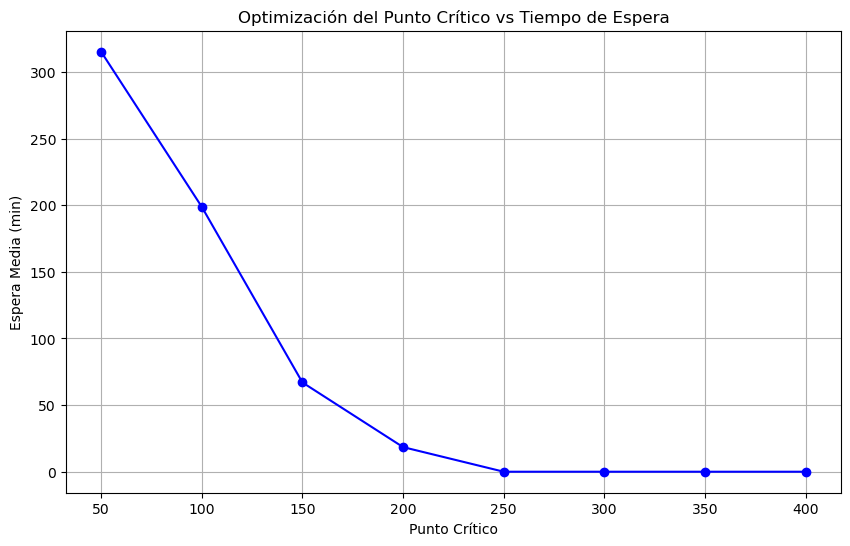


--- Resultados Finales ---
   Punto Crítico  Espera Media (min)
0             50          315.207143
1            100          198.789931
2            150           66.981642
3            200           18.470714
4            250            0.000000
5            300            0.000000
6            350            0.000000
7            400            0.000000


In [15]:
# --- Ejecución de la Simulación ---

def run_simulation(critical_point, verbose=False):
    env = simpy.Environment()
    fabrica = Fabrica(env, critical_point, verbose)
    
    env.process(check_stock(env, fabrica))
    for _ in range(2): env.process(fabricar_pieza(env, fabrica, 'rotor')) # Crear 2 procesos paralelos fabricando rotores
    for _ in range(2): env.process(fabricar_pieza(env, fabrica, 'stator'))
    for _ in range(3): env.process(ensamblar_motor(env, fabrica))
    
    env.run(until=7200) # 5 días
    
    avg_wait = np.mean(fabrica.stock_wait_times) if fabrica.stock_wait_times else 0
    p_def_rotor = (fabrica.defective_rotors / fabrica.total_rotors * 100) if fabrica.total_rotors > 0 else 0
    p_def_stator = (fabrica.defective_stators / fabrica.total_stators * 100) if fabrica.total_stators > 0 else 0
    
    return avg_wait, p_def_rotor, p_def_stator, fabrica.motores_finalizados

# Simulación de prueba
wait, pr, ps, total = run_simulation(100, verbose=True)

print(f"\n" + "="*30)
print(f"RESULTADOS FINALES (PC=100)")
print(f"="*30)
print(f"Motores totales creados: {total}")
print(f"Espera media stock: {wait:.2f} min")
print(f"Rotores defectuosos: {pr:.2f}%")
print(f"Estatores defectuosos: {ps:.2f}%")

# --- GRÁFICO DEL PUNTO CRÍTICO ---
puntos_test = range(50, 401, 50)
resultados_grafico = []

for cp in puntos_test:
    esperas = []
    for _ in range(10):
        w, _, _, _ = run_simulation(cp, verbose=False)
        esperas.append(w)
    resultados_grafico.append({'Punto Crítico': cp, 'Espera Media (min)': np.mean(esperas)})

df = pd.DataFrame(resultados_grafico)
plt.figure(figsize=(10, 6))
plt.plot(df['Punto Crítico'], df['Espera Media (min)'], marker='o', color='b')
plt.title('Optimización del Punto Crítico vs Tiempo de Espera')
plt.xlabel('Punto Crítico')
plt.ylabel('Espera Media (min)')
plt.grid(True)
plt.show()


print("\n--- Resultados Finales ---")
print(df)

In [16]:
wait, pr, ps, total = run_simulation(250, verbose=True)

print(f"\n" + "="*30)
print(f"RESULTADOS FINALES (PC=100)")
print(f"="*30)
print(f"Motores totales creados: {total}")
print(f"Espera media stock: {wait:.2f} min")
print(f"Rotores defectuosos: {pr:.2f}%")
print(f"Estatores defectuosos: {ps:.2f}%")


[01:01 día 0] FABRICACIÓN: rotor terminado.
[01:28 día 0] FABRICACIÓN: stator terminado.
[01:31 día 0] FABRICACIÓN: rotor terminado.
[01:51 día 0] FABRICACIÓN: rotor terminado.
[02:01 día 0] FABRICACIÓN: stator terminado.
[02:04 día 0] FABRICACIÓN: rotor terminado.
[02:51 día 0] FABRICACIÓN: stator terminado.
[03:00 día 0] FABRICACIÓN: rotor terminado.
[03:40 día 0] FABRICACIÓN: rotor terminado.
[03:47 día 0] FABRICACIÓN: stator terminado.
[03:59 día 0] FABRICACIÓN: rotor terminado.
[04:16 día 0] FABRICACIÓN: rotor terminado.
[04:24 día 0] FABRICACIÓN: stator terminado.
[04:41 día 0] ENSAMBLADO: Motor #1 enviado al almacén.
[04:54 día 0] FABRICACIÓN: stator terminado.
[04:55 día 0] FABRICACIÓN: rotor terminado.
[05:54 día 0] FABRICACIÓN: rotor terminado.
[06:17 día 0] FABRICACIÓN: rotor terminado.
[06:18 día 0] ENSAMBLADO: Motor #2 enviado al almacén.
[06:30 día 0] FABRICACIÓN: stator terminado.
[06:40 día 0] FABRICACIÓN: stator terminado.
[07:33 día 0] FABRICACIÓN: rotor terminado.
[0

Resultados experimento robots:
   Robots  Motores promedio
0       1              57.4
1       2              86.0
2       3              84.3
3       4              82.7


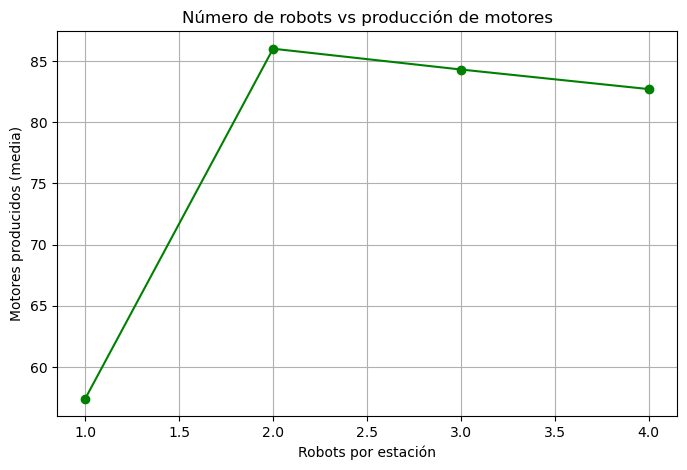

In [17]:
# Prueba: Número de robots

robots_list = [1, 2, 3, 4]

resultados_robots = []

# Modificar la clase Fabrica para cambiar número de robots
class Fabrica:
    def __init__(self, env, critical_point, rotor_robots=2, stator_robots=2, verbose=False):
        self.env = env
        self.critical_point = critical_point
        self.verbose = verbose 
        
        # Stocks de materiales
        self.copper = simpy.Container(env, init=500, capacity=500)
        self.aluminum = simpy.Container(env, init=500, capacity=500)
        
        # Recursos 
        self.rotor_robots = simpy.Resource(env, capacity=rotor_robots)
        self.stator_robots = simpy.Resource(env, capacity=stator_robots)
        self.rotor_inspectors = simpy.Resource(env, capacity=2)
        self.stator_inspectors = simpy.Resource(env, capacity=2)
        self.assembly_lines = simpy.Resource(env, capacity=3)
        
        # Almacenamiento intermedio y final
        self.ready_rotors = simpy.Store(env)
        self.ready_stators = simpy.Store(env)
        self.warehouse = simpy.Container(env, capacity=20, init=0)
        
        # Estadísticas
        self.motores_finalizados = 0  
        self.stock_wait_times = []
        self.defective_rotors = 0
        self.total_rotors = 0
        self.defective_stators = 0
        self.total_stators = 0
        
        self.copper_ordered = False
        self.aluminum_ordered = False

# Ajustamos run_simulation para aceptar número de robots
def run_simulation(critical_point, rotor_robots=2, stator_robots=2, verbose=False):
    env = simpy.Environment()
    fabrica = Fabrica(env, critical_point, rotor_robots, stator_robots, verbose)
    
    env.process(check_stock(env, fabrica))
    for _ in range(rotor_robots): env.process(fabricar_pieza(env, fabrica, 'rotor'))
    for _ in range(stator_robots): env.process(fabricar_pieza(env, fabrica, 'stator'))
    for _ in range(3): env.process(ensamblar_motor(env, fabrica))
    
    env.run(until=7200)
    
    return fabrica.motores_finalizados

# Ejecutamos experimento
for r in robots_list:
    motores = []
    for _ in range(10):  
        total = run_simulation(critical_point=100, rotor_robots=r, stator_robots=r)
        motores.append(total)
    
    resultados_robots.append({
        "Robots": r,
        "Motores promedio": np.mean(motores)
    })

df_robots = pd.DataFrame(resultados_robots)

# Imprimir tabla
print("Resultados experimento robots:")
print(df_robots)

# --- gráfico ---
plt.figure(figsize=(8,5))
plt.plot(df_robots["Robots"], df_robots["Motores promedio"], marker="o", color="green")
plt.title("Número de robots vs producción de motores")
plt.xlabel("Robots por estación")
plt.ylabel("Motores producidos (media)")
plt.grid(True)
plt.show()

Motores promedio fabricados: 110.8


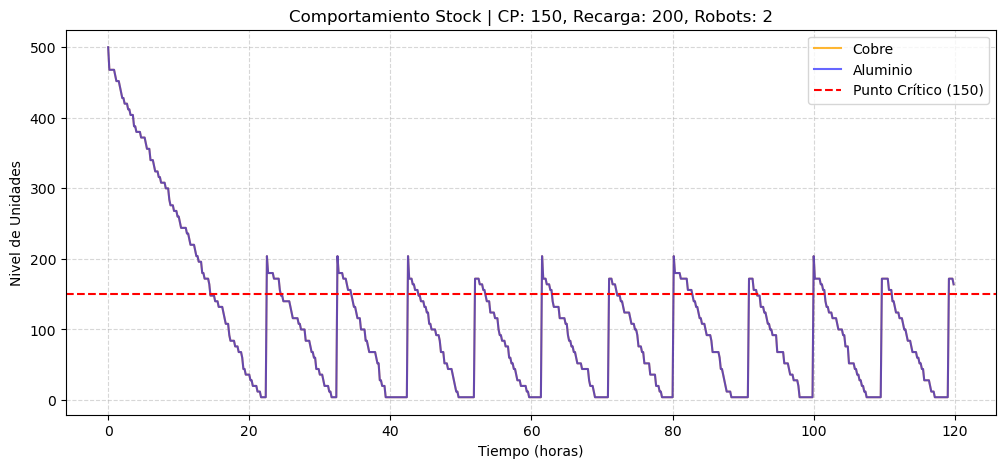

Motores promedio fabricados: 112.2


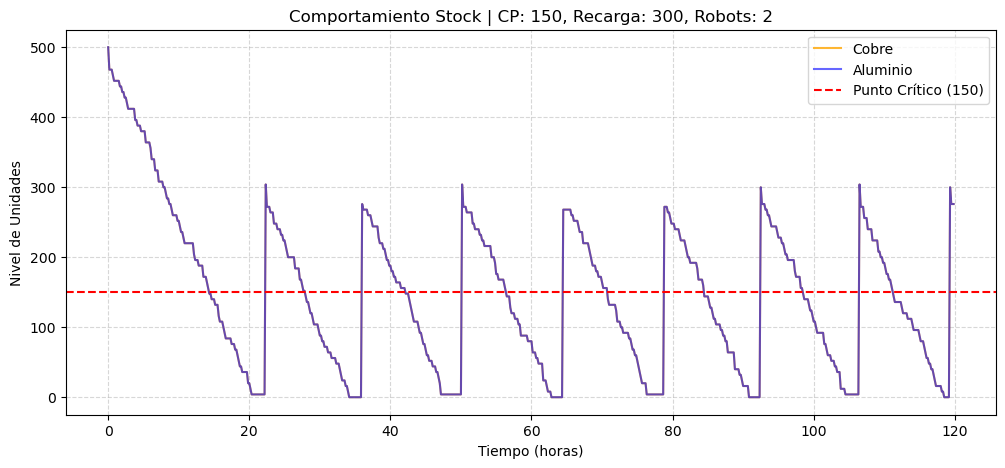

Motores promedio fabricados: 113.6


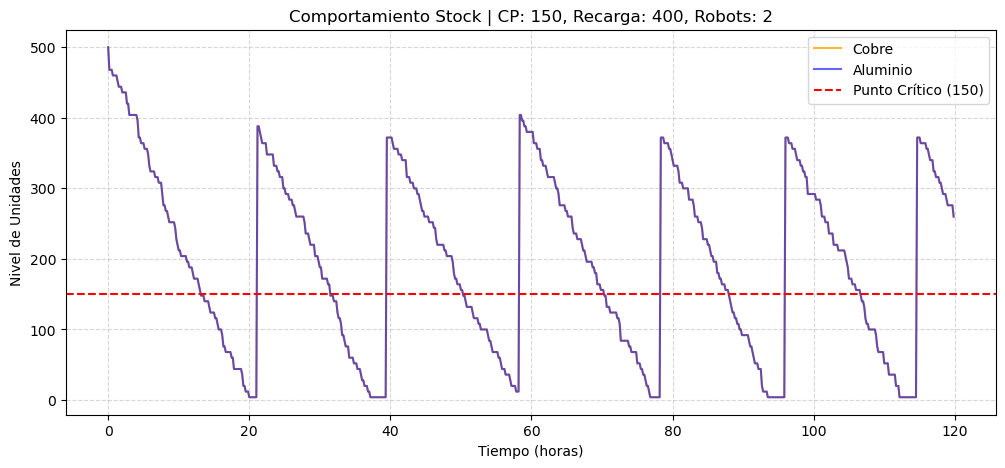

Motores promedio fabricados: 117.0


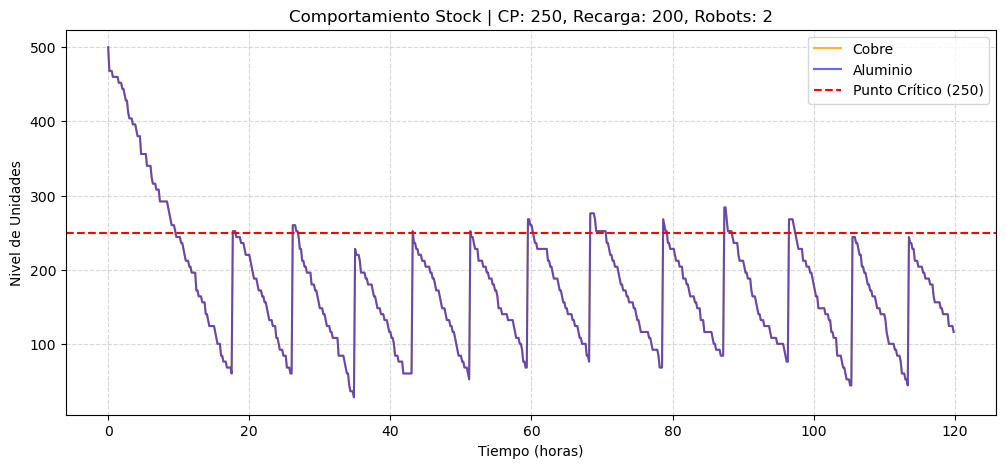

Motores promedio fabricados: 115.6


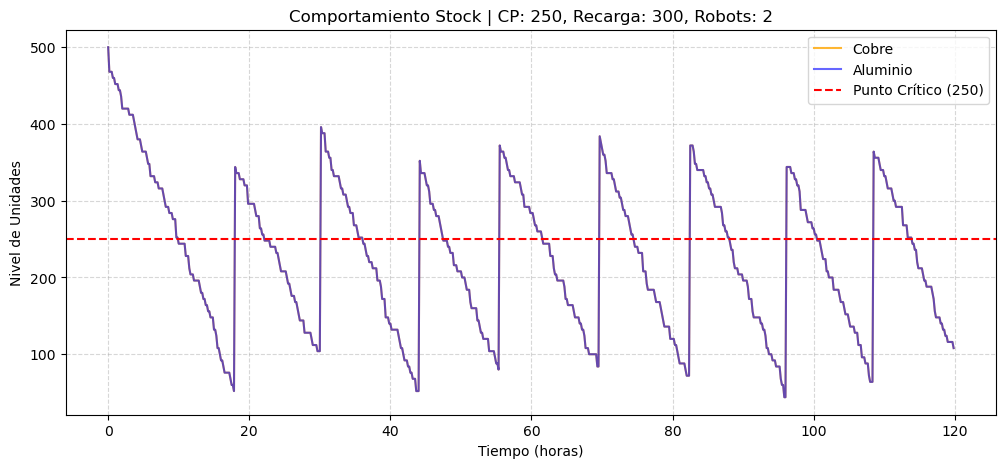

Motores promedio fabricados: 115.6


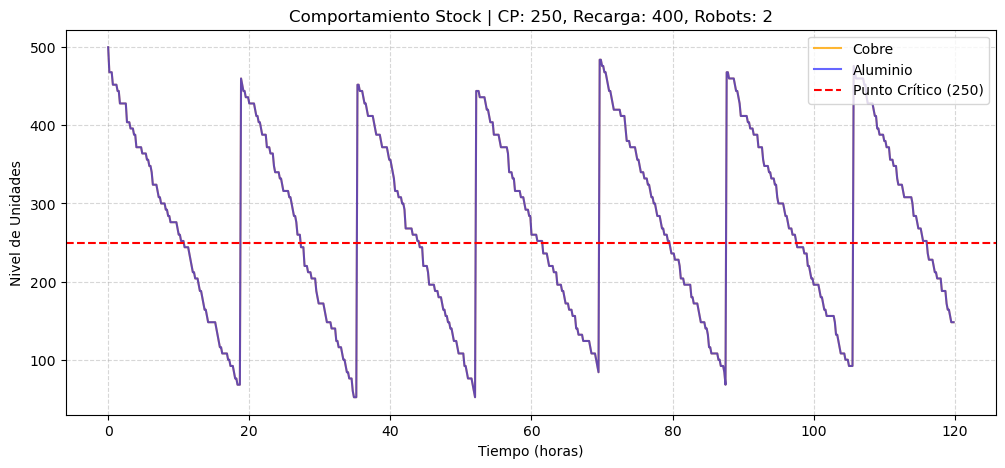

Motores promedio fabricados: 126.8


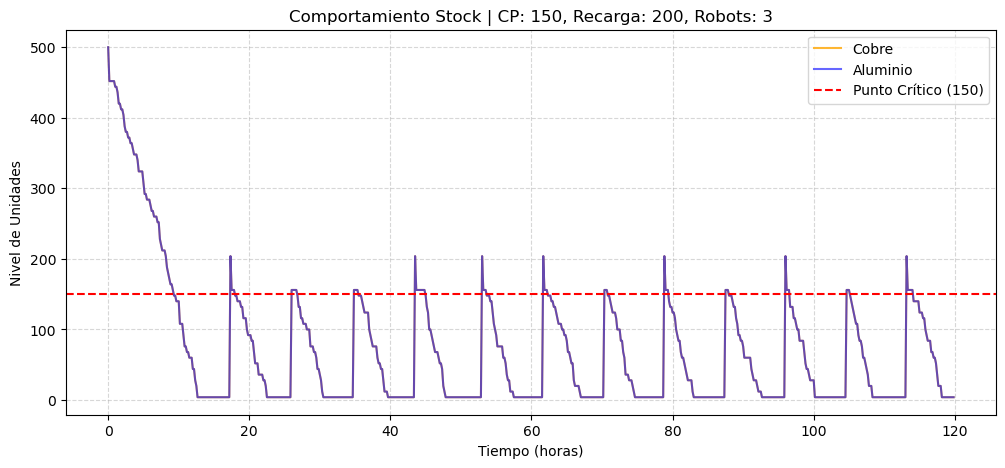

Motores promedio fabricados: 138.2


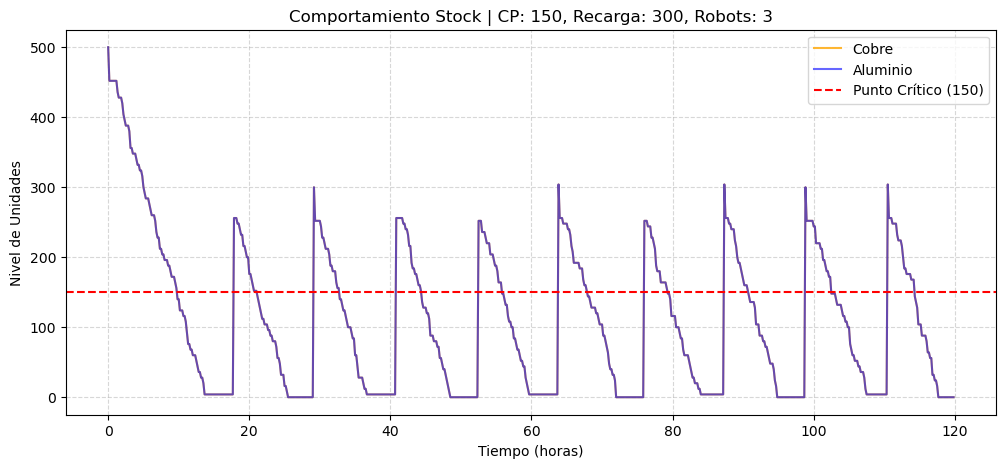

Motores promedio fabricados: 146.0


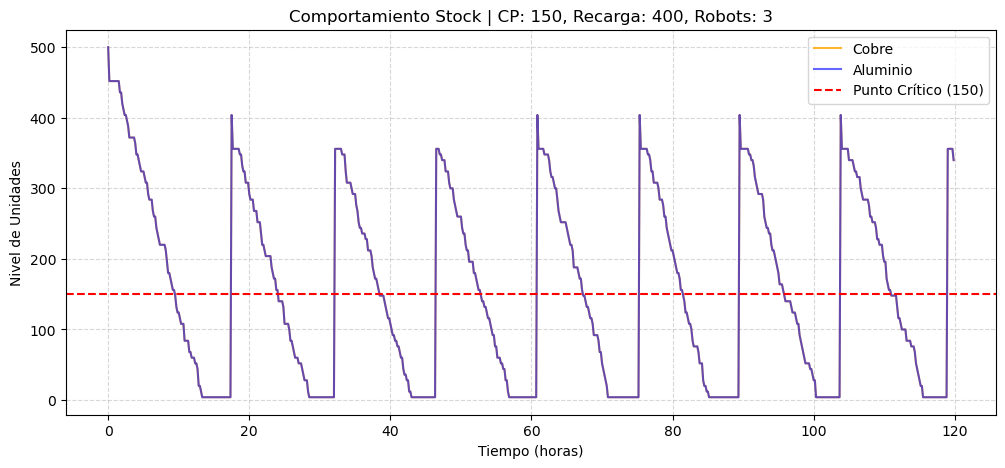

Motores promedio fabricados: 137.4


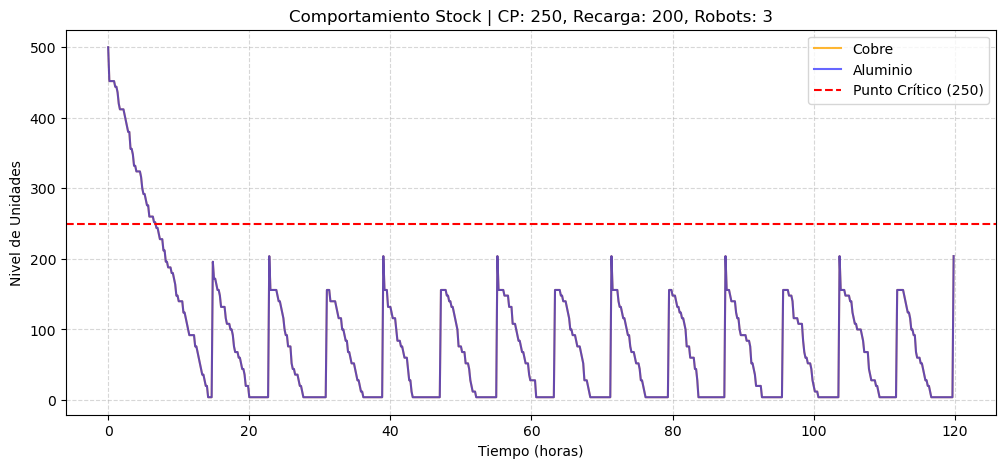

Motores promedio fabricados: 171.0


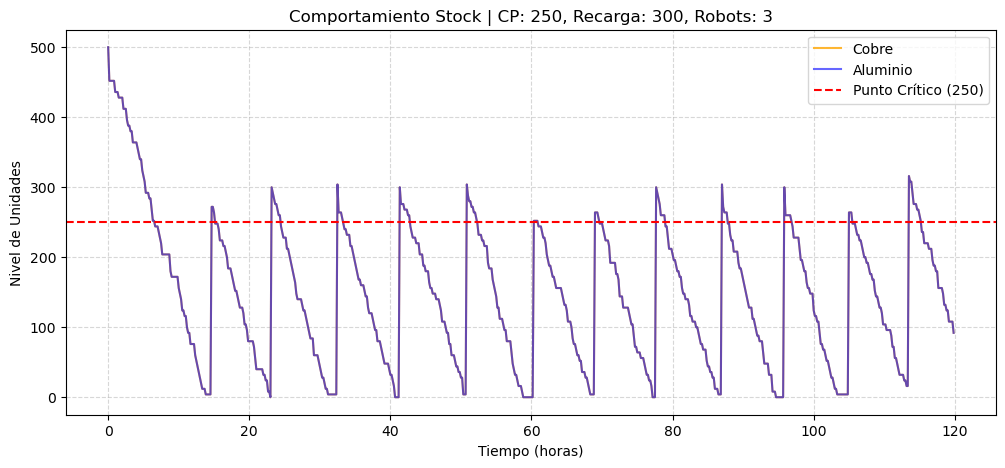

Motores promedio fabricados: 169.2


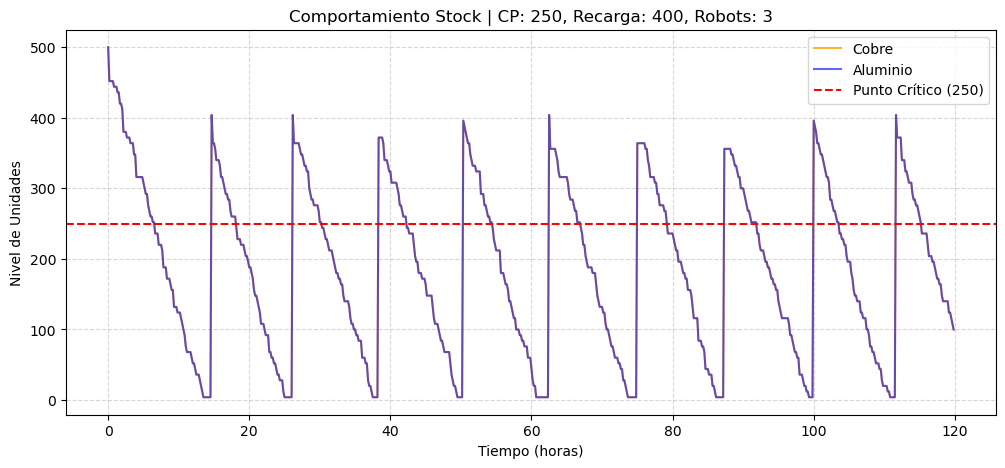

In [18]:
# --- Clase Fabrica Centralizada ---
class Fabrica:
    def __init__(self, env, cp, rq, n_robots, var_provider):
        self.env = env
        self.cp = cp                
        self.rq = rq                # Cantidad de recarga (Replenishment Qty)
        self.n_robots = n_robots    
        self.var_provider = var_provider 
        self.motores_fabricados = 0
        
        # Stocks
        self.copper = simpy.Container(env, init=500, capacity=500)
        self.aluminum = simpy.Container(env, init=500, capacity=500)
        
        # Recursos
        self.rotor_robots = simpy.Resource(env, capacity=n_robots)
        self.stator_robots = simpy.Resource(env, capacity=n_robots)
        self.rotor_inspectors = simpy.Resource(env, capacity=2)
        self.stator_inspectors = simpy.Resource(env, capacity=2)
        self.assembly_lines = simpy.Resource(env, capacity=3)
        
        self.ready_rotors = simpy.Store(env)
        self.ready_stators = simpy.Store(env)
        
        # Registro para el Gráfico
        self.stock_history = {'time': [], 'copper': [], 'aluminum': []}
        self.env.process(self.monitor_stock())
        
        self.copper_ordered = False
        self.aluminum_ordered = False

    def monitor_stock(self):
        """Registra los niveles de stock cada hora para graficar."""
        while True:
            self.stock_history['time'].append(self.env.now / 60) # Guardar en horas
            self.stock_history['copper'].append(self.copper.level)
            self.stock_history['aluminum'].append(self.aluminum.level)
            yield self.env.timeout(10) # Muestreo cada 10 min

# --- Procesos de Soporte ---

def refill_stock(env, fabrica, material):
    if material == 'cobre': fabrica.copper_ordered = True
    else: fabrica.aluminum_ordered = True
    
    # Tiempo de espera fijo 8h
    wait_time = 8 * 60
    yield env.timeout(wait_time)
    
    add = min(fabrica.rq, 500 - (fabrica.copper.level if material == 'cobre' else fabrica.aluminum.level))
    if material == 'cobre':
        yield fabrica.copper.put(add)
        fabrica.copper_ordered = False
    else:
        yield fabrica.aluminum.put(add)
        fabrica.aluminum_ordered = False

def check_stock_logic(env, fabrica):
    while True:
        if fabrica.copper.level < fabrica.cp and not fabrica.copper_ordered:
            env.process(refill_stock(env, fabrica, 'cobre'))
        if fabrica.aluminum.level < fabrica.cp and not fabrica.aluminum_ordered:
            env.process(refill_stock(env, fabrica, 'aluminio'))
        yield env.timeout(5)

def fabricar_pieza(env, fabrica, tipo):
    resource = fabrica.rotor_robots if tipo == 'rotor' else fabrica.stator_robots
    mean_time = 60 if tipo == 'rotor' else 120
    
    while True:
        with resource.request() as req:
            yield req
            
            while fabrica.copper.level < 8 or fabrica.aluminum.level < 8:
                yield env.timeout(1)
            
            yield fabrica.copper.get(8)
            yield fabrica.aluminum.get(8)
            
            yield env.timeout(max(30, random.normalvariate(mean_time, 30)))
            
            # Guardar pieza terminada
            if tipo == 'rotor':
                yield fabrica.ready_rotors.put(1)
            else:
                yield fabrica.ready_stators.put(1)

def ensamblar_motor(env, fabrica):
    while True:
        with fabrica.assembly_lines.request() as req:
            yield req
            
            # Esperar a tener ambas piezas
            yield fabrica.ready_rotors.get()
            yield fabrica.ready_stators.get()
            
            # Tiempo de ensamblaje
            yield env.timeout(90)  # ajustable
            
            # Motor terminado
            fabrica.motores_fabricados += 1

def plot_stock_levels(stock_data_list, cp, rq, robots, var):
    plt.figure(figsize=(12, 5))
    # Graficamos solo la primera simulación del lote para no saturar el gráfico
    data = stock_data_list[0]
    plt.plot(data['time'], data['copper'], label='Cobre', color='orange', alpha=0.8)
    plt.plot(data['time'], data['aluminum'], label='Aluminio', color='blue', alpha=0.6)
    
    plt.axhline(y=cp, color='r', linestyle='--', label=f'Punto Crítico ({cp})')
    
    plt.title(f"Comportamiento Stock | CP: {cp}, Recarga: {rq}, Robots: {robots}")
    plt.xlabel('Tiempo (horas)')
    plt.ylabel('Nivel de Unidades')
    plt.legend(loc='upper right')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.show()

# --- Orquestador ---

def run_experiment(cp, rq, robots, var):
    all_sims_data = []
    motores_totales = []
    
    for _ in range(5):
        env = simpy.Environment()
        f = Fabrica(env, cp, rq, robots, var)
        
        env.process(check_stock_logic(env, f))
        
        for _ in range(robots):
            env.process(fabricar_pieza(env, f, 'rotor'))
            env.process(fabricar_pieza(env, f, 'stator'))
        
        for _ in range(3):
            env.process(ensamblar_motor(env, f))
            
        env.run(until=7200)
        
        all_sims_data.append(f.stock_history)
        motores_totales.append(f.motores_fabricados)
    
    print(f"Motores promedio fabricados: {sum(motores_totales)/len(motores_totales)}")
    
    plot_stock_levels(all_sims_data, cp, rq, robots, var)
    return all_sims_data, motores_totales

# --- Ejecución de Pruebas Variando Parámetros ---

# Parámetros a probar
puntos_criticos = [150 ,250]
cantidades_recarga = [200, 300, 400]
robots_opciones = [2, 3]

for n_rob in robots_opciones:
    for cp in puntos_criticos:
        for rq in cantidades_recarga:
            data = run_experiment(cp, rq, n_rob, var=False)